In [1]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile

from google.colab.patches import cv2_imshow

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path = '/content/drive/MyDrive/ai09-level1-project.zip'
output_dir = '/content/ai09-project01/'
os.makedirs(output_dir, exist_ok=True)
zip_file = zipfile.ZipFile(dataset_path)
zip_file.extractall(path=output_dir)

In [4]:
data_root = "/content/ai09-project01/sprint_ai_project1_data"

train_image_dir = os.path.join(data_root, "train_images")
train_annotation_dir = os.path.join(data_root, "train_annotations")
test_image_dir = os.path.join(data_root, "test_images")

print("Train image dir:", train_image_dir)
print("Train annotation dir:", train_annotation_dir)
print("Test image dir:", test_image_dir)

Train image dir: /content/ai09-project01/sprint_ai_project1_data/train_images
Train annotation dir: /content/ai09-project01/sprint_ai_project1_data/train_annotations
Test image dir: /content/ai09-project01/sprint_ai_project1_data/test_images


In [5]:
def safe_get(d, keys, default=None):
    for k in keys:
        if k in d and d[k] not in [None, ""]:
            return d[k]
    return default

In [6]:
def get_image_files(image_dir, exts=(".png", ".jpg", ".jpeg")):
    image_files = sorted([
        f for f in os.listdir(image_dir)
        if f.lower().endswith(exts)
    ])
    print("Number of image files:", len(image_files))
    print("Sample image files:", image_files[:5])
    return image_files

In [7]:
def build_images_df(image_dir, image_files):
    rows = []

    for file_name in image_files:
        img_path = os.path.join(image_dir, file_name)
        img = cv2.imread(img_path)

        if img is None:
            rows.append({
                "file_name": file_name,
                "width": None,
                "height": None,
                "channel": None,
                "is_broken": True
            })
            continue

        h, w, c = img.shape
        rows.append({
            "file_name": file_name,
            "width": w,
            "height": h,
            "channel": c,
            "is_broken": False
        })

    images_df = pd.DataFrame(rows)
    images_df["image_key"] = images_df["file_name"].apply(lambda x: os.path.splitext(x)[0])

    return images_df

In [8]:
def inspect_annotation_tree(annotation_root, max_items=20):
    print("[Annotation Directory Inspection]")

    shown = 0
    for root, dirs, files in os.walk(annotation_root):
        rel_root = os.path.relpath(root, annotation_root)
        print(f"Directory: {rel_root}")
        print("Subdirectories:", dirs[:10])
        print("Files:", files[:10])
        print("-" * 80)

        shown += 1
        if shown >= max_items:
            break

In [9]:
inspect_annotation_tree(train_annotation_dir, max_items=15)

[Annotation Directory Inspection]
Directory: .
Subdirectories: ['K-003351-029667-031863_json', 'K-003351-020014-036637_json', 'K-003483-025469-028763-035206_json', 'K-003351-013900-035206_json', 'K-003351-020238-032310_json', 'K-003351-020014-035206_json', 'K-003351-016232-041768_json', 'K-003351-019232-038162_json', 'K-003351-016232-019232_json', 'K-003351-018357-036637_json']
Files: []
--------------------------------------------------------------------------------
Directory: K-003351-029667-031863_json
Subdirectories: ['K-029667', 'K-031863', 'K-003351']
Files: []
--------------------------------------------------------------------------------
Directory: K-003351-029667-031863_json/K-029667
Subdirectories: []
Files: ['K-003351-029667-031863_0_2_0_2_70_000_200.json', 'K-003351-029667-031863_0_2_0_2_75_000_200.json']
--------------------------------------------------------------------------------
Directory: K-003351-029667-031863_json/K-031863
Subdirectories: []
Files: ['K-003351-0296

In [10]:
def preview_json_examples(annotation_root, max_json=5):
    count = 0

    for root, dirs, files in os.walk(annotation_root):
        json_files = [f for f in files if f.lower().endswith(".json")]

        for jf in json_files:
            json_path = os.path.join(root, jf)

            print("JSON path:", json_path)
            with open(json_path, "r", encoding="utf-8") as f:
                data = json.load(f)

            print("Top-level type:", type(data))
            if isinstance(data, dict):
                print("Keys:", list(data.keys()))
            print("Content preview:")
            print(data)
            print("=" * 100)

            count += 1
            if count >= max_json:
                return

In [11]:
preview_json_examples(train_annotation_dir, max_json=2)

JSON path: /content/ai09-project01/sprint_ai_project1_data/train_annotations/K-003351-029667-031863_json/K-029667/K-003351-029667-031863_0_2_0_2_70_000_200.json
Top-level type: <class 'dict'>
Keys: ['images', 'type', 'annotations', 'categories']
Content preview:
{'images': [{'file_name': 'K-003351-029667-031863_0_2_0_2_70_000_200.png', 'width': 976, 'height': 1280, 'imgfile': 'K-003351-029667-031863_0_2_0_2_70_000_200.png', 'drug_N': 'K-029667', 'drug_S': '정상알약', 'back_color': '연회색 배경', 'drug_dir': '앞면', 'light_color': '주백색', 'camera_la': 70, 'camera_lo': 0, 'size': 200, 'dl_idx': '29667', 'dl_mapping_code': 'K-029667', 'dl_name': '리바로정 4mg', 'dl_name_en': 'Livalo Tab. 4mg', 'img_key': 'http://connectdi.com/design/img/drug/147426609286000173.jpg', 'dl_material': '피타바스타틴칼슘', 'dl_material_en': 'Pitavastatin Calcium', 'dl_custom_shape': '정제, 저작정', 'dl_company': '제이더블유중외제약(주)', 'dl_company_en': 'Jw Pharmaceutical', 'di_company_mf': '', 'di_company_mf_en': '', 'item_seq': 201205253, 'di_ite

In [12]:
def find_first_bbox(obj):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if k == "bbox" and isinstance(v, list) and len(v) == 4:
                return v
            result = find_first_bbox(v)
            if result is not None:
                return result
    elif isinstance(obj, list):
        for item in obj:
            result = find_first_bbox(item)
            if result is not None:
                return result
    return None


def parse_annotation_json(json_path, image_folder_name=None):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    rows = []

    # Case 1: COCO-style JSON
    if isinstance(data, dict) and "annotations" in data:
        annotations = data.get("annotations", [])
        images = data.get("images", [])
        categories = data.get("categories", [])

        image_info = images[0] if len(images) > 0 else {}
        image_id = safe_get(image_info, ["id"], default=None)
        file_name = safe_get(image_info, ["file_name"], default=None)

        category_map = {}
        for cat in categories:
            cat_id = safe_get(cat, ["id"], default=None)
            cat_name = safe_get(cat, ["name"], default=None)
            category_map[cat_id] = cat_name

        for ann in annotations:
            bbox = safe_get(ann, ["bbox"], default=None)
            category_id = safe_get(ann, ["category_id"], default=None)

            rows.append({
                "image_key": image_folder_name,
                "json_file": os.path.basename(json_path),
                "file_name_from_json": file_name,
                "image_id": image_id,
                "bbox": bbox,
                "category_id": category_id,
                "category_name": category_map.get(category_id, None),
                "dl_idx": safe_get(image_info, ["dl_idx"]),
                "dl_name": safe_get(image_info, ["dl_name"]),
                "drug_shape": safe_get(image_info, ["drug_shape"]),
                "color_class1": safe_get(image_info, ["color_class1"]),
                "color_class2": safe_get(image_info, ["color_class2"]),
                "line_front": safe_get(image_info, ["line_front"]),
                "line_back": safe_get(image_info, ["line_back"]),
                "print_front": safe_get(image_info, ["print_front"]),
                "print_back": safe_get(image_info, ["print_back"]),
                "json_path": json_path
            })

        return rows

    # Case 2: single-object JSON
    bbox = safe_get(data, ["bbox", "box", "bounding_box"], default=None)
    if bbox is None:
        bbox = find_first_bbox(data)

    category_id = safe_get(data, ["category_id", "class_id", "label_id"], default=None)
    category_name = safe_get(data, ["category_name", "class_name", "label", "name", "dl_name"], default=None)

    rows.append({
        "image_key": image_folder_name,
        "json_file": os.path.basename(json_path),
        "file_name_from_json": safe_get(data, ["file_name"]),
        "image_id": safe_get(data, ["image_id", "id"]),
        "bbox": bbox,
        "category_id": category_id,
        "category_name": category_name,
        "dl_idx": safe_get(data, ["dl_idx"]),
        "dl_name": safe_get(data, ["dl_name"]),
        "drug_shape": safe_get(data, ["drug_shape"]),
        "color_class1": safe_get(data, ["color_class1"]),
        "color_class2": safe_get(data, ["color_class2"]),
        "line_front": safe_get(data, ["line_front"]),
        "line_back": safe_get(data, ["line_back"]),
        "print_front": safe_get(data, ["print_front"]),
        "print_back": safe_get(data, ["print_back"]),
        "json_path": json_path
    })

    return rows

In [13]:
def build_annotations_df(annotation_root):
    rows = []
    folder_count = 0
    json_count = 0

    for root, dirs, files in os.walk(annotation_root):
        if root != annotation_root:
            folder_count += 1

        json_files = [f for f in files if f.lower().endswith(".json")]

        for jf in json_files:
            json_path = os.path.join(root, jf)
            rel_dir = os.path.relpath(root, annotation_root)
            dir_parts = rel_dir.split(os.sep)

            # Use JSON file stem first
            json_stem = os.path.splitext(jf)[0]
            image_key = json_stem

            try:
                parsed_rows = parse_annotation_json(json_path, image_folder_name=image_key)

                for row in parsed_rows:
                    row["relative_dir"] = rel_dir
                    row["dir_depth"] = len(dir_parts)
                    rows.append(row)

                json_count += 1

            except Exception as e:
                rows.append({
                    "image_key": image_key,
                    "json_file": jf,
                    "file_name_from_json": None,
                    "image_id": None,
                    "bbox": None,
                    "category_id": None,
                    "category_name": None,
                    "dl_idx": None,
                    "dl_name": None,
                    "drug_shape": None,
                    "color_class1": None,
                    "color_class2": None,
                    "line_front": None,
                    "line_back": None,
                    "print_front": None,
                    "print_back": None,
                    "json_path": json_path,
                    "relative_dir": rel_dir,
                    "dir_depth": len(dir_parts),
                    "parse_error": str(e)
                })

    annotations_df = pd.DataFrame(rows)

    print("Number of scanned folders:", folder_count)
    print("Total number of JSON files:", json_count)
    print("annotations_df shape:", annotations_df.shape)

    return annotations_df

In [14]:
image_files = get_image_files(train_image_dir)
images_df = build_images_df(train_image_dir, image_files)
annotations_df = build_annotations_df(train_annotation_dir)

Number of image files: 232
Sample image files: ['K-001900-016548-019607-029451_0_2_0_2_70_000_200.png', 'K-001900-016548-019607-029451_0_2_0_2_75_000_200.png', 'K-001900-016548-019607-029451_0_2_0_2_90_000_200.png', 'K-001900-016548-019607-033009_0_2_0_2_70_000_200.png', 'K-001900-016548-019607-033009_0_2_0_2_75_000_200.png']
Number of scanned folders: 481
Total number of JSON files: 763
annotations_df shape: (763, 19)


In [15]:
print("[images_df head]")
display(images_df.head())

print("[annotations_df head]")
display(annotations_df.head())

[images_df head]


,file_name,width,height,channel,is_broken,image_key
0,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,976,1280,3,False,K-001900-016548-019607-029451_0_2_0_2_70_000_200
1,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,976,1280,3,False,K-001900-016548-019607-029451_0_2_0_2_75_000_200
2,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,976,1280,3,False,K-001900-016548-019607-029451_0_2_0_2_90_000_200
3,K-001900-016548-019607-033009_0_2_0_2_70_000_2...,976,1280,3,False,K-001900-016548-019607-033009_0_2_0_2_70_000_200
4,K-001900-016548-019607-033009_0_2_0_2_75_000_2...,976,1280,3,False,K-001900-016548-019607-033009_0_2_0_2_75_000_200


[annotations_df head]


,image_key,json_file,file_name_from_json,image_id,bbox,category_id,category_name,dl_idx,dl_name,drug_shape,color_class1,color_class2,line_front,line_back,print_front,print_back,json_path,relative_dir,dir_depth
0,K-003351-029667-031863_0_2_0_2_70_000_200,K-003351-029667-031863_0_2_0_2_70_000_200.json,K-003351-029667-031863_0_2_0_2_70_000_200.png,208,"[580, 336, 227, 227]",29667,리바로정 4mg,29667,리바로정 4mg,원형,노랑,None,None,-,마크203,분할선,/content/ai09-project01/sprint_ai_project1_dat...,K-003351-029667-031863_json/K-029667,2
1,K-003351-029667-031863_0_2_0_2_75_000_200,K-003351-029667-031863_0_2_0_2_75_000_200.json,K-003351-029667-031863_0_2_0_2_75_000_200.png,209,"[120, 662, 234, 232]",29667,리바로정 4mg,29667,리바로정 4mg,원형,노랑,None,None,-,마크203,분할선,/content/ai09-project01/sprint_ai_project1_dat...,K-003351-029667-031863_json/K-029667,2
2,K-003351-029667-031863_0_2_0_2_70_000_200,K-003351-029667-031863_0_2_0_2_70_000_200.json,K-003351-029667-031863_0_2_0_2_70_000_200.png,208,"[178, 249, 205, 203]",31863,아질렉트정(라사길린메실산염),31863,아질렉트정(라사길린메실산염),원형,하양,None,None,None,GIL 1,None,/content/ai09-project01/sprint_ai_project1_dat...,K-003351-029667-031863_json/K-031863,2
3,K-003351-029667-031863_0_2_0_2_75_000_200,K-003351-029667-031863_0_2_0_2_75_000_200.json,K-003351-029667-031863_0_2_0_2_75_000_200.png,209,"[559, 786, 209, 214]",31863,아질렉트정(라사길린메실산염),31863,아질렉트정(라사길린메실산염),원형,하양,None,None,None,GIL 1,None,/content/ai09-project01/sprint_ai_project1_dat...,K-003351-029667-031863_json/K-031863,2
4,K-003351-029667-031863_0_2_0_2_70_000_200,K-003351-029667-031863_0_2_0_2_70_000_200.json,K-003351-029667-031863_0_2_0_2_70_000_200.png,208,"[178, 249, 205, 203]",3351,일양하이트린정 2mg,3351,일양하이트린정 2mg,원형,주황,None,-,None,I분할선Y,HT,/content/ai09-project01/sprint_ai_project1_dat...,K-003351-029667-031863_json/K-003351,2


In [16]:
print("[Image Summary]")
print("Total number of images:", len(images_df))
print("Number of broken images:", int(images_df["is_broken"].sum()))
print("Number of unique widths:", images_df["width"].nunique(dropna=True))
print("Number of unique heights:", images_df["height"].nunique(dropna=True))
print("Channel values:", sorted(images_df["channel"].dropna().unique().tolist()))

print("\n[Image Metadata Description]")
display(images_df.describe(include="all"))

[Image Summary]
Total number of images: 232
Number of broken images: 0
Number of unique widths: 1
Number of unique heights: 1
Channel values: [3]

[Image Metadata Description]


,file_name,width,height,channel,is_broken,image_key
count,232,232.0,232.0,232.0,232,232
unique,232,NaN,NaN,NaN,1,232
top,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,NaN,NaN,NaN,False,K-001900-016548-019607-029451_0_2_0_2_70_000_200
freq,1,NaN,NaN,NaN,232,1
mean,NaN,976.0,1280.0,3.0,NaN,NaN
std,NaN,0.0,0.0,0.0,NaN,NaN
min,NaN,976.0,1280.0,3.0,NaN,NaN
25%,NaN,976.0,1280.0,3.0,NaN,NaN
50%,NaN,976.0,1280.0,3.0,NaN,NaN
75%,NaN,976.0,1280.0,3.0,NaN,NaN


In [17]:
print("[Annotation Summary]")
print("Total number of annotation rows:", len(annotations_df))
print("Columns:", list(annotations_df.columns))

if "bbox" in annotations_df.columns:
    valid_bbox = annotations_df["bbox"].apply(lambda x: isinstance(x, list) and len(x) == 4)
    print("Number of valid bboxes:", int(valid_bbox.sum()))
    print("Number of invalid bboxes:", int((~valid_bbox).sum()))

if "category_id" in annotations_df.columns:
    print("Number of unique category_id values:", annotations_df["category_id"].nunique(dropna=True))

if "category_name" in annotations_df.columns:
    print("Number of unique category_name values:", annotations_df["category_name"].nunique(dropna=True))

if "dl_name" in annotations_df.columns:
    print("Number of unique dl_name values:", annotations_df["dl_name"].nunique(dropna=True))

[Annotation Summary]
Total number of annotation rows: 763
Columns: ['image_key', 'json_file', 'file_name_from_json', 'image_id', 'bbox', 'category_id', 'category_name', 'dl_idx', 'dl_name', 'drug_shape', 'color_class1', 'color_class2', 'line_front', 'line_back', 'print_front', 'print_back', 'json_path', 'relative_dir', 'dir_depth']
Number of valid bboxes: 763
Number of invalid bboxes: 0
Number of unique category_id values: 56
Number of unique category_name values: 56
Number of unique dl_name values: 56


In [18]:
image_keys = set(images_df["image_key"])
ann_keys = set(annotations_df["image_key"].dropna())

print("[Image-Annotation Key Matching]")
print("Number of keys found only in images:", len(image_keys - ann_keys))
print("Number of keys found only in annotations:", len(ann_keys - image_keys))
print("Sample keys found only in images:", list(image_keys - ann_keys)[:5])
print("Sample keys found only in annotations:", list(ann_keys - image_keys)[:5])

[Image-Annotation Key Matching]
Number of keys found only in images: 0
Number of keys found only in annotations: 0
Sample keys found only in images: []
Sample keys found only in annotations: []


In [19]:
if "category_name" in annotations_df.columns and annotations_df["category_name"].notna().sum() > 0:
    class_series = annotations_df["category_name"].fillna("UNKNOWN")
elif "dl_name" in annotations_df.columns and annotations_df["dl_name"].notna().sum() > 0:
    class_series = annotations_df["dl_name"].fillna("UNKNOWN")
elif "category_id" in annotations_df.columns:
    class_series = annotations_df["category_id"].fillna(-1).astype(str)
elif "dl_idx" in annotations_df.columns:
    class_series = annotations_df["dl_idx"].fillna("UNKNOWN").astype(str)
else:
    class_series = pd.Series(["UNKNOWN"] * len(annotations_df))

class_counts = class_series.value_counts()

print("[Descending Order]")
display(class_counts.head(100).to_frame(name="count"))

[Descending Order]


,count
category_name,
일양하이트린정 2mg,153
기넥신에프정(은행엽엑스)(수출용),45
아토젯정 10/40mg,37
크레스토정 20mg,23
아토르바정 10mg,22
리피토정 20mg,21
뉴로메드정(옥시라세탐),20
플라빅스정 75mg,20
로수젯정10/5밀리그램,19


In [20]:
obj_per_img = annotations_df.groupby("image_key").size()

print("[Objects per Image Summary]")
display(obj_per_img.describe().to_frame(name="value"))

[Objects per Image Summary]


,value
count,232.000000
mean,3.288793
std,0.516611
min,2.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,4.000000


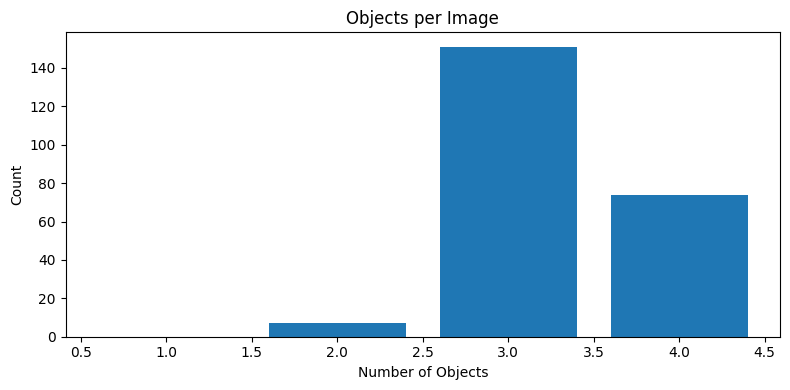

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(obj_per_img, bins=range(1, int(obj_per_img.max()) + 2), align="left", rwidth=0.8)
plt.title("Objects per Image")
plt.xlabel("Number of Objects")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [22]:
bbox_df = annotations_df[annotations_df["bbox"].apply(lambda x: isinstance(x, list) and len(x) == 4)].copy()

bbox_df["x"] = bbox_df["bbox"].apply(lambda x: x[0])
bbox_df["y"] = bbox_df["bbox"].apply(lambda x: x[1])
bbox_df["w"] = bbox_df["bbox"].apply(lambda x: x[2])
bbox_df["h"] = bbox_df["bbox"].apply(lambda x: x[3])
bbox_df["area_calc"] = bbox_df["w"] * bbox_df["h"]
bbox_df["aspect_ratio"] = bbox_df["w"] / (bbox_df["h"] + 1e-6)

print("[BBox Summary]")
display(bbox_df[["w", "h", "area_calc", "aspect_ratio"]].describe())

[BBox Summary]


,w,h,area_calc,aspect_ratio
count,763.000000,763.000000,763.000000,763.000000
mean,250.007864,265.764089,70384.792923,0.991525
std,73.772225,95.652529,42608.636579,0.268859
min,125.000000,126.000000,23250.000000,0.396084
25%,189.500000,191.000000,36672.000000,0.828811
50%,230.000000,227.000000,53600.000000,1.000000
75%,285.000000,316.000000,93492.500000,1.040713
max,529.000000,664.000000,272435.000000,2.108374


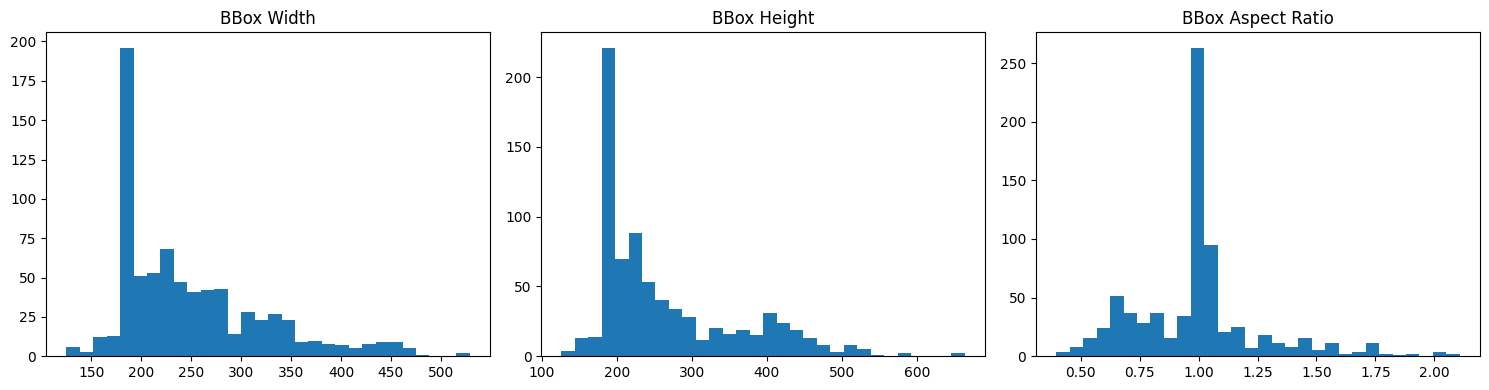

In [23]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(bbox_df["w"], bins=30)
plt.title("BBox Width")

plt.subplot(1, 3, 2)
plt.hist(bbox_df["h"], bins=30)
plt.title("BBox Height")

plt.subplot(1, 3, 3)
plt.hist(bbox_df["aspect_ratio"], bins=30)
plt.title("BBox Aspect Ratio")

plt.tight_layout()
plt.show()

In [24]:
metadata_cols = [
    "dl_name", "dl_idx", "drug_shape", "color_class1",
    "color_class2", "line_front", "line_back",
    "print_front", "print_back"
]

for col in metadata_cols:
    if col in annotations_df.columns:
        print(f"[Top values for {col}]")
        display(annotations_df[col].value_counts(dropna=False).head(10).to_frame(name="count"))
        print("-" * 80)

[Top values for dl_name]


,count
dl_name,
일양하이트린정 2mg,153
기넥신에프정(은행엽엑스)(수출용),45
아토젯정 10/40mg,37
크레스토정 20mg,23
아토르바정 10mg,22
리피토정 20mg,21
뉴로메드정(옥시라세탐),20
플라빅스정 75mg,20
로수젯정10/5밀리그램,19


--------------------------------------------------------------------------------
[Top values for dl_idx]


,count
dl_idx,
3351,153
3483,45
35206,37
16262,23
21325,22
16232,21
3832,20
20238,20
36637,19


--------------------------------------------------------------------------------
[Top values for drug_shape]


...

--------------------------------------------------------------------------------
[Top values for print_front]


,count
print_front,
I분할선Y,153
SK,45
마크,42
337,37
None,34
YH,25
ZD452220,23
ATV,21
75,20


--------------------------------------------------------------------------------
[Top values for print_back]


,count
print_back,
None,274
HT,153
분할선,60
G40,45
20,37
10,22
1171,20
Y분할선H,18
JIC,16


--------------------------------------------------------------------------------


In [25]:
print("[Sample Annotation Rows]")
display(annotations_df.sample(min(5, len(annotations_df)), random_state=42))

[Sample Annotation Rows]


,image_key,json_file,file_name_from_json,image_id,bbox,category_id,category_name,dl_idx,dl_name,drug_shape,color_class1,color_class2,line_front,line_back,print_front,print_back,json_path,relative_dir,dir_depth
357,K-003351-020014-022074_0_2_0_2_70_000_200,K-003351-020014-022074_0_2_0_2_70_000_200.json,K-003351-020014-022074_0_2_0_2_70_000_200.png,781,"[578, 278, 341, 315]",20014,마도파정,20014,마도파정,원형,분홍,None,+,+,RO분할선C분할선HE분할선마크분할선,십자분할선,/content/ai09-project01/sprint_ai_project1_dat...,K-003351-020014-022074_json/K-020014,2
259,K-003351-016232-032310_0_2_0_2_90_000_200,K-003351-016232-032310_0_2_0_2_90_000_200.json,K-003351-016232-032310_0_2_0_2_90_000_200.png,597,"[391, 220, 185, 182]",3351,일양하이트린정 2mg,3351,일양하이트린정 2mg,원형,주황,None,-,None,I분할선Y,HT,/content/ai09-project01/sprint_ai_project1_dat...,K-003351-016232-032310_json/K-003351,2
749,K-003351-016262-020014_0_2_0_2_75_000_200,K-003351-016262-020014_0_2_0_2_75_000_200.json,K-003351-016262-020014_0_2_0_2_75_000_200.png,1286,"[25, 720, 253, 244]",16262,크레스토정 20mg,16262,크레스토정 20mg,원형,분홍,None,None,None,ZD452220,None,/content/ai09-project01/sprint_ai_project1_dat...,K-003351-016262-020014_json/K-016262,2
193,K-003351-016262-033880_0_2_0_2_90_000_200,K-003351-016262-033880_0_2_0_2_90_000_200.json,K-003351-016262-033880_0_2_0_2_90_000_200.png,1365,"[357, 213, 183, 183]",3351,일양하이트린정 2mg,3351,일양하이트린정 2mg,원형,주황,None,-,None,I분할선Y,HT,/content/ai09-project01/sprint_ai_project1_dat...,K-003351-016262-033880_json/K-003351,2
333,K-001900-016551-029345-033208_0_2_0_2_90_000_200,K-001900-016551-029345-033208_0_2_0_2_90_000_2...,K-001900-016551-029345-033208_0_2_0_2_90_000_2...,285,"[683, 835, 212, 202]",33208,에스원엠프정 20mg,33208,에스원엠프정 20mg,원형,분홍,None,None,None,20S,None,/content/ai09-project01/sprint_ai_project1_dat...,K-001900-016551-029345-033208_json/K-033208,2


In [26]:
import os
import shutil
import yaml
import pandas as pd
from collections import defaultdict

In [27]:
def convert_loaded_annotations_to_yolo(
    images_df,
    annotations_df,
    train_image_dir,
    output_root,
    class_source="auto",
    copy_images=True,
    split_name="train"
):
    def is_valid_bbox(bbox):
        return isinstance(bbox, list) and len(bbox) == 4 and bbox[2] > 0 and bbox[3] > 0

    def xywh_to_yolo(img_w, img_h, bbox):
        x, y, w, h = bbox
        x_center = (x + w / 2.0) / img_w
        y_center = (y + h / 2.0) / img_h
        w = w / img_w
        h = h / img_h
        return x_center, y_center, w, h

    def choose_class_series(df, class_source):
        if class_source == "category_name" and "category_name" in df.columns:
            return df["category_name"]
        elif class_source == "dl_name" and "dl_name" in df.columns:
            return df["dl_name"]
        elif class_source == "category_id" and "category_id" in df.columns:
            return df["category_id"].astype(str)
        elif class_source == "dl_idx" and "dl_idx" in df.columns:
            return df["dl_idx"].astype(str)
        elif class_source == "auto":
            if "category_name" in df.columns and df["category_name"].notna().sum() > 0:
                return df["category_name"]
            elif "dl_name" in df.columns and df["dl_name"].notna().sum() > 0:
                return df["dl_name"]
            elif "category_id" in df.columns and df["category_id"].notna().sum() > 0:
                return df["category_id"].astype(str)
            elif "dl_idx" in df.columns and df["dl_idx"].notna().sum() > 0:
                return df["dl_idx"].astype(str)
            else:
                raise ValueError("No valid class column found in annotations_df.")
        else:
            raise ValueError(f"Invalid class_source: {class_source}")

    image_out_dir = os.path.join(output_root, "images", split_name)
    label_out_dir = os.path.join(output_root, "labels", split_name)

    os.makedirs(image_out_dir, exist_ok=True)
    os.makedirs(label_out_dir, exist_ok=True)

    class_series = choose_class_series(annotations_df, class_source).fillna("UNKNOWN").astype(str)

    unique_classes = sorted(class_series.unique().tolist())
    class_to_id = {cls_name: idx for idx, cls_name in enumerate(unique_classes)}
    id_to_class = {idx: cls_name for cls_name, idx in class_to_id.items()}

    ann_df = annotations_df.copy()
    ann_df["selected_class_name"] = class_series
    ann_df = ann_df[ann_df["bbox"].apply(is_valid_bbox)].copy()

    image_info_map = images_df.set_index("image_key")[["file_name", "width", "height"]].to_dict("index")
    grouped = ann_df.groupby("image_key")

    written_label_files = 0
    copied_image_files = 0
    skipped_images = 0
    skipped_empty_labels = 0

    for image_key, group in grouped:
        if image_key not in image_info_map:
            skipped_images += 1
            continue

        file_name = image_info_map[image_key]["file_name"]
        img_w = image_info_map[image_key]["width"]
        img_h = image_info_map[image_key]["height"]

        if pd.isna(img_w) or pd.isna(img_h) or img_w <= 0 or img_h <= 0:
            skipped_images += 1
            continue

        src_img_path = os.path.join(train_image_dir, file_name)
        if not os.path.exists(src_img_path):
            skipped_images += 1
            continue

        stem = os.path.splitext(file_name)[0]
        label_path = os.path.join(label_out_dir, f"{stem}.txt")

        yolo_lines = []

        for _, row in group.iterrows():
            bbox = row["bbox"]
            cls_name = str(row["selected_class_name"])
            cls_id = class_to_id[cls_name]

            x_center, y_center, w, h = xywh_to_yolo(img_w, img_h, bbox)

            x_center = min(max(x_center, 0.0), 1.0)
            y_center = min(max(y_center, 0.0), 1.0)
            w = min(max(w, 0.0), 1.0)
            h = min(max(h, 0.0), 1.0)

            if w <= 0 or h <= 0:
                continue

            yolo_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")

        if len(yolo_lines) == 0:
            skipped_empty_labels += 1
            continue

        with open(label_path, "w", encoding="utf-8") as f:
            f.write("\n".join(yolo_lines))
        written_label_files += 1

        if copy_images:
            dst_img_path = os.path.join(image_out_dir, file_name)
            if not os.path.exists(dst_img_path):
                shutil.copy2(src_img_path, dst_img_path)
            copied_image_files += 1

    yaml_path = os.path.join(output_root, "dataset.yaml")
    yaml_data = {
        "path": output_root,
        "train": f"images/{split_name}",
        "val": f"images/{split_name}",
        "names": {i: id_to_class[i] for i in sorted(id_to_class.keys())}
    }

    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.safe_dump(yaml_data, f, allow_unicode=True, sort_keys=False)

    print("YOLO conversion completed.")
    print("Output root:", output_root)
    print("Image output dir:", image_out_dir)
    print("Label output dir:", label_out_dir)
    print("Number of classes:", len(class_to_id))
    print("Number of written label files:", written_label_files)
    print("Number of copied image files:", copied_image_files)
    print("Number of skipped images:", skipped_images)
    print("Number of skipped empty labels:", skipped_empty_labels)
    print("dataset.yaml path:", yaml_path)

    return {
        "class_to_id": class_to_id,
        "id_to_class": id_to_class,
        "yaml_path": yaml_path,
        "image_dir": image_out_dir,
        "label_dir": label_out_dir
    }

In [28]:
annotations_df = annotations_df.copy()

if "file_name_from_json" in annotations_df.columns:
    mask = annotations_df["file_name_from_json"].notna()
    annotations_df.loc[mask, "image_key"] = annotations_df.loc[mask, "file_name_from_json"].apply(
        lambda x: os.path.splitext(os.path.basename(x))[0]
    )

print("Updated image_key using file_name_from_json where available.")

Updated image_key using file_name_from_json where available.


In [29]:
image_files = get_image_files(train_image_dir)
images_df = build_images_df(train_image_dir, image_files)
annotations_df = build_annotations_df(train_annotation_dir)

annotations_df = annotations_df.copy()
if "file_name_from_json" in annotations_df.columns:
    mask = annotations_df["file_name_from_json"].notna()
    annotations_df.loc[mask, "image_key"] = annotations_df.loc[mask, "file_name_from_json"].apply(
        lambda x: os.path.splitext(os.path.basename(x))[0]
    )

yolo_info = convert_loaded_annotations_to_yolo(
    images_df=images_df,
    annotations_df=annotations_df,
    train_image_dir=train_image_dir,
    output_root="/content/yolo_pill_dataset",
    class_source="auto",
    copy_images=True,
    split_name="train"
)

Number of image files: 232
Sample image files: ['K-001900-016548-019607-029451_0_2_0_2_70_000_200.png', 'K-001900-016548-019607-029451_0_2_0_2_75_000_200.png', 'K-001900-016548-019607-029451_0_2_0_2_90_000_200.png', 'K-001900-016548-019607-033009_0_2_0_2_70_000_200.png', 'K-001900-016548-019607-033009_0_2_0_2_75_000_200.png']
Number of scanned folders: 481
Total number of JSON files: 763
annotations_df shape: (763, 19)
YOLO conversion completed.
Output root: /content/yolo_pill_dataset
Image output dir: /content/yolo_pill_dataset/images/train
Label output dir: /content/yolo_pill_dataset/labels/train
Number of classes: 56
Number of written label files: 232
Number of copied image files: 232
Number of skipped images: 0
Number of skipped empty labels: 0
dataset.yaml path: /content/yolo_pill_dataset/dataset.yaml


In [30]:
# target_image_name = "K-001900-016548-019607-029451_0_2_0_2_70_000_200.png"
# target_image_key = os.path.splitext(target_image_name)[0]

# print("[Rows in annotations_df]")
# target_rows = annotations_df[annotations_df["image_key"] == target_image_key].copy()
# print("Number of rows:", len(target_rows))
# display(target_rows[["image_key", "json_file", "bbox", "category_name", "dl_name", "json_path"]])

# print("\n[YOLO label file]")
# label_path = os.path.join(yolo_info["label_dir"], f"{target_image_key}.txt")
# print("Label path:", label_path)

# if os.path.exists(label_path):
#     with open(label_path, "r", encoding="utf-8") as f:
#         lines = f.read().strip().splitlines()
#     print("Number of YOLO lines:", len(lines))
#     print(lines)
# else:
#     print("Label file does not exist.")

[Rows in annotations_df]
Number of rows: 4


,image_key,json_file,bbox,category_name,dl_name,json_path
69,K-001900-016548-019607-029451_0_2_0_2_70_000_200,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,"[657, 287, 155, 150]",스토가정 10mg,스토가정 10mg,/content/ai09-project01/sprint_ai_project1_dat...
72,K-001900-016548-019607-029451_0_2_0_2_70_000_200,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,"[144, 799, 239, 239]",가바토파정 100mg,가바토파정 100mg,/content/ai09-project01/sprint_ai_project1_dat...
75,K-001900-016548-019607-029451_0_2_0_2_70_000_200,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,"[644, 845, 189, 190]",보령부스파정 5mg,보령부스파정 5mg,/content/ai09-project01/sprint_ai_project1_dat...
78,K-001900-016548-019607-029451_0_2_0_2_70_000_200,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,"[108, 218, 392, 264]",레일라정,레일라정,/content/ai09-project01/sprint_ai_project1_dat...



[YOLO label file]
Label path: /content/yolo_pill_dataset/labels/train/K-001900-016548-019607-029451_0_2_0_2_70_000_200.txt
Number of YOLO lines: 4
['24 0.752561 0.282813 0.158811 0.117188', '0 0.269980 0.717578 0.244877 0.186719', '22 0.756660 0.734375 0.193648 0.148438', '10 0.311475 0.273438 0.401639 0.206250']


In [31]:
label_files = sorted(os.listdir(yolo_info["label_dir"]))
print("Number of label files:", len(label_files))
print("Sample label file:", label_files[:3])

sample_label_path = os.path.join(yolo_info["label_dir"], label_files[0])
with open(sample_label_path, "r", encoding="utf-8") as f:
    print(f.read())

Number of label files: 232
Sample label file: ['K-001900-016548-019607-029451_0_2_0_2_70_000_200.txt', 'K-001900-016548-019607-029451_0_2_0_2_75_000_200.txt', 'K-001900-016548-019607-029451_0_2_0_2_90_000_200.txt']
24 0.752561 0.282813 0.158811 0.117188
0 0.269980 0.717578 0.244877 0.186719
22 0.756660 0.734375 0.193648 0.148438
10 0.311475 0.273438 0.401639 0.206250


In [32]:
print("Number of train images:", len(os.listdir(yolo_info["image_dir"])))
print("Number of train labels:", len(os.listdir(yolo_info["label_dir"])))
print("dataset.yaml path:", yolo_info["yaml_path"])
print("Number of classes:", len(yolo_info["class_to_id"]))
print("Sample classes:", list(yolo_info["class_to_id"].items())[:10])

Number of train images: 232
Number of train labels: 232
dataset.yaml path: /content/yolo_pill_dataset/dataset.yaml
Number of classes: 56
Sample classes: [('가바토파정 100mg', 0), ('글리아타민연질캡슐', 1), ('글리틴정(콜린알포세레이트)', 2), ('기넥신에프정(은행엽엑스)(수출용)', 3), ('노바스크정 5mg', 4), ('놀텍정 10mg', 5), ('뉴로메드정(옥시라세탐)', 6), ('다보타민큐정 10mg/병', 7), ('동아가바펜틴정 800mg', 8), ('라비에트정 20mg', 9)]


In [33]:
with open(yolo_info["yaml_path"], "r", encoding="utf-8") as f:
    print(f.read())

path: /content/yolo_pill_dataset
train: images/train
val: images/train
names:
  0: 가바토파정 100mg
  1: 글리아타민연질캡슐
  2: 글리틴정(콜린알포세레이트)
  3: 기넥신에프정(은행엽엑스)(수출용)
  4: 노바스크정 5mg
  5: 놀텍정 10mg
  6: 뉴로메드정(옥시라세탐)
  7: 다보타민큐정 10mg/병
  8: 동아가바펜틴정 800mg
  9: 라비에트정 20mg
  10: 레일라정
  11: 로수바미브정 10/20mg
  12: 로수젯정10/5밀리그램
  13: 리렉스펜정 300mg/PTP
  14: 리리카캡슐 150mg
  15: 리바로정 4mg
  16: 리피로우정 20mg
  17: 리피토정 20mg
  18: 마도파정
  19: 맥시부펜이알정 300mg
  20: 무코스타정(레바미피드)(비매품)
  21: 뮤테란캡슐 100mg
  22: 보령부스파정 5mg
  23: 비모보정 500/20mg
  24: 스토가정 10mg
  25: 신바로정
  26: 써스펜8시간이알서방정 650mg
  27: 아모잘탄정 5/100mg
  28: 아빌리파이정 10mg
  29: 아질렉트정(라사길린메실산염)
  30: 아토르바정 10mg
  31: 아토젯정 10/40mg
  32: 알드린정
  33: 에빅사정(메만틴염산염)(비매품)
  34: 에스원엠프정 20mg
  35: 에어탈정(아세클로페낙)
  36: 엑스포지정 5/160mg
  37: 오마코연질캡슐(오메가-3-산에틸에스테르90)
  38: 울트라셋이알서방정
  39: 일양하이트린정 2mg
  40: 자누메트엑스알서방정 100/1000mg
  41: 자누메트정 50/850mg
  42: 자누비아정 50mg
  43: 제미메트서방정 50/1000mg
  44: 졸로푸트정 100mg
  45: 종근당글리아티린연질캡슐(콜린알포세레이트) 
  46: 카나브정 60mg
  47: 카발린캡슐 25mg
  48: 콜리네이트연질캡슐 400mg

In [34]:
from sklearn.model_selection import KFold

image_dir = yolo_info["image_dir"]
label_dir = yolo_info["label_dir"]
class_to_id = yolo_info["class_to_id"]

image_files = sorted([
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

pairs = []
missing_labels = []

for img_file in image_files:
    stem = os.path.splitext(img_file)[0]
    label_file = f"{stem}.txt"
    label_path = os.path.join(label_dir, label_file)

    if os.path.exists(label_path):
        pairs.append((img_file, label_file))
    else:
        missing_labels.append(img_file)

print("Number of image-label pairs:", len(pairs))
print("Number of images without label files:", len(missing_labels))
print("Sample pairs:", pairs[:3])

Number of image-label pairs: 232
Number of images without label files: 0
Sample pairs: [('K-001900-016548-019607-029451_0_2_0_2_70_000_200.png', 'K-001900-016548-019607-029451_0_2_0_2_70_000_200.txt'), ('K-001900-016548-019607-029451_0_2_0_2_75_000_200.png', 'K-001900-016548-019607-029451_0_2_0_2_75_000_200.txt'), ('K-001900-016548-019607-029451_0_2_0_2_90_000_200.png', 'K-001900-016548-019607-029451_0_2_0_2_90_000_200.txt')]


In [35]:
def make_yolo_kfold_dataset(
    pairs,
    image_dir,
    label_dir,
    output_root,
    class_to_id,
    n_splits=5,
    random_state=42,
    shuffle=True
):
    os.makedirs(output_root, exist_ok=True)

    names_dict = {idx: name for name, idx in class_to_id.items()}
    indices = list(range(len(pairs)))

    kf = KFold(
        n_splits=n_splits,
        shuffle=shuffle,
        random_state=random_state
    )

    fold_yaml_paths = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
        fold_root = os.path.join(output_root, f"fold_{fold_idx}")
        fold_train_img_dir = os.path.join(fold_root, "images", "train")
        fold_val_img_dir = os.path.join(fold_root, "images", "val")
        fold_train_lbl_dir = os.path.join(fold_root, "labels", "train")
        fold_val_lbl_dir = os.path.join(fold_root, "labels", "val")

        os.makedirs(fold_train_img_dir, exist_ok=True)
        os.makedirs(fold_val_img_dir, exist_ok=True)
        os.makedirs(fold_train_lbl_dir, exist_ok=True)
        os.makedirs(fold_val_lbl_dir, exist_ok=True)

        for idx in train_idx:
            img_file, lbl_file = pairs[idx]

            shutil.copy2(
                os.path.join(image_dir, img_file),
                os.path.join(fold_train_img_dir, img_file)
            )
            shutil.copy2(
                os.path.join(label_dir, lbl_file),
                os.path.join(fold_train_lbl_dir, lbl_file)
            )

        for idx in val_idx:
            img_file, lbl_file = pairs[idx]

            shutil.copy2(
                os.path.join(image_dir, img_file),
                os.path.join(fold_val_img_dir, img_file)
            )
            shutil.copy2(
                os.path.join(label_dir, lbl_file),
                os.path.join(fold_val_lbl_dir, lbl_file)
            )

        yaml_path = os.path.join(fold_root, "dataset.yaml")
        yaml_data = {
            "path": fold_root,
            "train": "images/train",
            "val": "images/val",
            "names": names_dict
        }

        with open(yaml_path, "w", encoding="utf-8") as f:
            yaml.safe_dump(yaml_data, f, allow_unicode=True, sort_keys=False)

        fold_yaml_paths.append(yaml_path)

        print(f"[Fold {fold_idx}]")
        print("Train samples:", len(train_idx))
        print("Val samples:", len(val_idx))
        print("YAML path:", yaml_path)
        print("-" * 80)

    return fold_yaml_paths

In [36]:
fold_yaml_paths = make_yolo_kfold_dataset(
    pairs=pairs,
    image_dir=image_dir,
    label_dir=label_dir,
    output_root="/content/yolo_pill_dataset_kfold",
    class_to_id=class_to_id,
    n_splits=5,
    random_state=42,
    shuffle=True
)

[Fold 1]
Train samples: 185
Val samples: 47
YAML path: /content/yolo_pill_dataset_kfold/fold_1/dataset.yaml
--------------------------------------------------------------------------------
[Fold 2]
Train samples: 185
Val samples: 47
YAML path: /content/yolo_pill_dataset_kfold/fold_2/dataset.yaml
--------------------------------------------------------------------------------
[Fold 3]
Train samples: 186
Val samples: 46
YAML path: /content/yolo_pill_dataset_kfold/fold_3/dataset.yaml
--------------------------------------------------------------------------------
[Fold 4]
Train samples: 186
Val samples: 46
YAML path: /content/yolo_pill_dataset_kfold/fold_4/dataset.yaml
--------------------------------------------------------------------------------
[Fold 5]
Train samples: 186
Val samples: 46
YAML path: /content/yolo_pill_dataset_kfold/fold_5/dataset.yaml
--------------------------------------------------------------------------------


In [37]:
print("Number of fold yaml files:", len(fold_yaml_paths))
print("Fold yaml paths:")
for p in fold_yaml_paths:
    print(p)

Number of fold yaml files: 5
Fold yaml paths:
/content/yolo_pill_dataset_kfold/fold_1/dataset.yaml
/content/yolo_pill_dataset_kfold/fold_2/dataset.yaml
/content/yolo_pill_dataset_kfold/fold_3/dataset.yaml
/content/yolo_pill_dataset_kfold/fold_4/dataset.yaml
/content/yolo_pill_dataset_kfold/fold_5/dataset.yaml


In [38]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.7 MB/s eta 0:00:00


In [39]:
from ultralytics import YOLO

kfold_results = []

for fold_idx, yaml_path in enumerate(fold_yaml_paths, start=1):
    print(f"\n========== Fold {fold_idx} / {len(fold_yaml_paths)} ==========")
    print("Using data yaml:", yaml_path)

    model = YOLO("yolo11n.yaml")

    results = model.train(
        data=yaml_path,
        epochs=50,
        imgsz=800,
        batch=32,
        project="yolo11_kfold_runs_v2_800",
        name=f"scratch_fold_{fold_idx}",

        # optimization
        lr0=0.01,
        lrf=0.01,
        weight_decay=0.0005,
        warmup_epochs=3.0,

        # augmentation
        degrees=10.0,
        fliplr=0.5,
        flipud=0.3,
        hsv_h=0.01,
        hsv_s=0.2,
        hsv_v=0.2,
        mosaic=0.0,
        mixup=0.0
    )

    kfold_results.append({
        "fold": fold_idx,
        "yaml_path": yaml_path,
        "results": results
    })

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

========== Fold 1 / 5 ==========
Using data yaml: /content/yolo_pill_dataset_kfold/fold_1/dataset.yaml
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_pill_dataset_kfold/fold_1/dataset.yaml, degrees=10.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fli

KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

kfold_results_pretrained = []

for fold_idx, yaml_path in enumerate(fold_yaml_paths, start=1):
    print(f"\n========== Fold {fold_idx} / {len(fold_yaml_paths)} ==========")
    print("Using data yaml:", yaml_path)

    model = YOLO("yolo11n.pt")

    results = model.train(
    data=yolo_info["yaml_path"],
    epochs=30,
    imgsz=800,
    batch=32,
    freeze=10,

    lr0=0.005,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=3.0,

    # loss weights
    box=7.5,
    cls=1.0,
    dfl=1.5,

    degrees=10.0,
    fliplr=0.5,
    flipud=0.3,
    hsv_h=0.01,
    hsv_s=0.2,
    hsv_v=0.2,
    mosaic=0.0,
    mixup=0.0
    )

    kfold_results.append({
        "fold": fold_idx,
        "yaml_path": yaml_path,
        "results": results
    })